# Finite Strain Contact

Compute the deformation of an elastic half-ring pushed against an elastic block. The contact algorithm is based on [2] using the penalty method. The results are compared with those reported in [1, pp. 110-114].

## Reference

[1] Rabii Mlika, *Nitsche Method for Frictional Contact and Self-Contact: Mathematical and Numerical Study*, 2019.

[2] K. A. Fischer and P. Wriggers, *Frictionless 2D Contact formulations for finite deformations based on the mortar method*, 2005.

In [28]:
import gmsh
import dolfinx.fem.petsc
from mpi4py import MPI
import viskex
import pyvista as pv
import ufl
import numpy as np
from petsc4py import PETSc
from pathlib import Path
import shutil
from matplotlib import pyplot as plt

rank = 0
comm = MPI.COMM_WORLD
pv.set_jupyter_backend("static")

# Results folder
results = Path("./results_contact_finite_strain")
if results.exists():
    shutil.rmtree(results)
results.mkdir()

# Mesh properties
pdim = 0
bdim = 1
gdim = 2

BODY_1          = 1
BODY_2          = 2
BODY_3          = 3

ARCH_CONTACT    = 4
BASE_BOTTOM     = 5
BASE_TOP        = 6

ARCH_ENDS       = 7
MIDDLE          = 8
DISP            = 9
SYM             = 10

element = ("Lagrange", 1, (gdim,))

# Contact properties

N1 = lambda xi: (1 - xi)
N2 = lambda xi: xi

penalty_eps = 7.5e3

num_gauss = 4
gauss_xi = np.array([
    0.0694318442029737,
    0.3300094782075719,
    0.6699905217924281,
    0.9305681557970262
])
gauss_w = np.array([
    0.1739274225687269,
    0.3260725774312730,
    0.3260725774312730,
    0.1739274225687269
])

# Material properties
E1 = 1e3
E2 = 1e5
E3 = 3e2
nu = 0.3

# Iteration tolerances
newton_iter         = 200
steps               = 140
U_goal              = -70
tol                 = 1e-6
alpha               = 1.0
max_contact_iter    = 20
max_backtracks      = 10
verbose_newton      = False

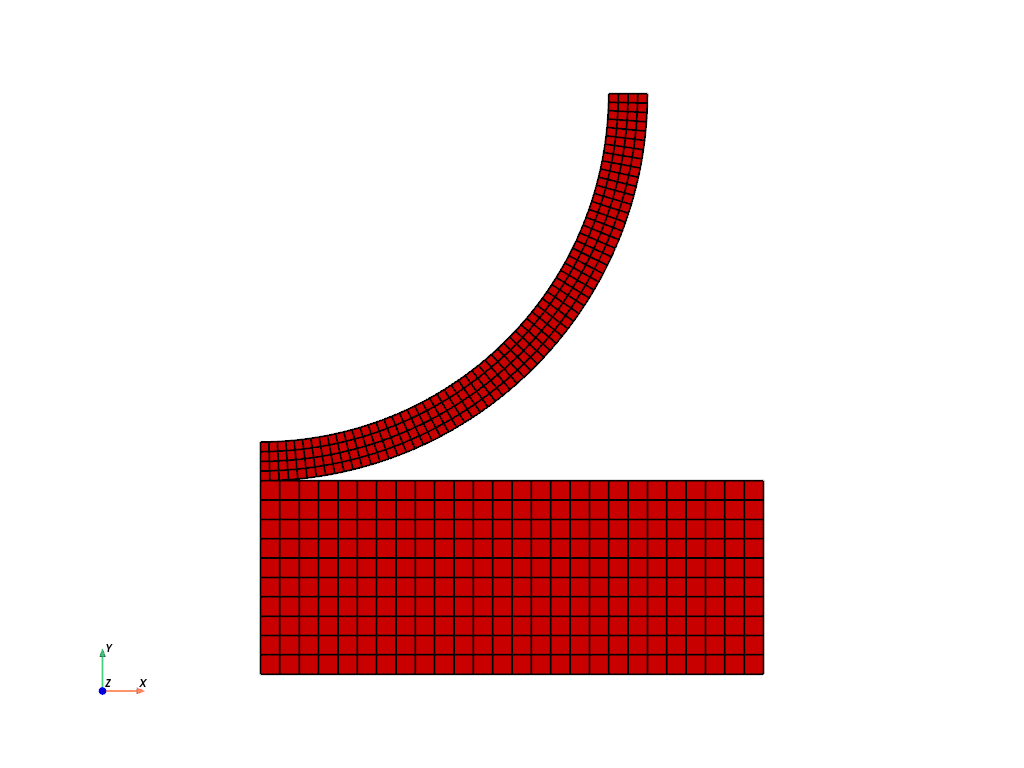

In [29]:
gmsh.initialize()
gmsh.model.add("elastic_half_ring")
gmsh.option.set_number("General.Terminal", 0)

occ = gmsh.model.occ

# Lines and Surfaces
occ.add_circle(0, 0, 0, 100, angle1=3/2*np.pi, angle2=0)
occ.add_circle(0, 0, 0, 95, angle1=3/2*np.pi, angle2=0)
occ.add_circle(0, 0, 0, 90, angle1=3/2*np.pi, angle2=0)

occ.add_line(2, 4)
occ.add_line(4, 6)
occ.add_line(5, 3)
occ.add_line(3, 1)

occ.add_curve_loop([1, 4, -2, 7])
occ.add_curve_loop([2, 5, -3, 6])
occ.add_plane_surface([1])
occ.add_plane_surface([2])
occ.add_rectangle(0, -100-50, 0, 130, 50)

occ.synchronize()

# Physical tags
gmsh.model.add_physical_group(gdim, [1], BODY_1)
gmsh.model.add_physical_group(gdim, [2], BODY_2)
gmsh.model.add_physical_group(gdim, [3], BODY_3)

gmsh.model.add_physical_group(bdim, [1], ARCH_CONTACT)
gmsh.model.add_physical_group(bdim, [8], BASE_BOTTOM)
gmsh.model.add_physical_group(bdim, [10], BASE_TOP)

gmsh.model.add_physical_group(bdim, [4, 5], ARCH_ENDS)
gmsh.model.add_physical_group(pdim, [5], MIDDLE)
gmsh.model.add_physical_group(bdim, [6, 7, 11], SYM)

# Transfinite mesh
for curve_id in (4, 5, 6, 7):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 2 + 1)

for curve_id in (1, 2, 3):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 65 + 1)

for curve_id in (11, -9):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 10 + 1)

for curve_id in (8, -10):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 26 + 1)

gmsh.model.mesh.set_transfinite_surface(1)
gmsh.model.mesh.set_transfinite_surface(2)
gmsh.model.mesh.set_transfinite_surface(3)
gmsh.model.mesh.generate(gdim)
gmsh.model.mesh.recombine()
mesh_data = dolfinx.io.gmsh.model_to_mesh(gmsh.model, comm, rank, gdim)
gmsh.finalize()

domain          = mesh_data.mesh
facet_tags      = mesh_data.facet_tags
cell_tags       = mesh_data.cell_tags
ridge_tags      = mesh_data.ridge_tags

middle_idx      = ridge_tags.find(MIDDLE).item()
slave_facets    = facet_tags.find(ARCH_CONTACT)
master_facets   = facet_tags.find(BASE_TOP)

tdim            = domain.topology.dim
fdim            = tdim - 1
x_current       = domain.geometry.x[:, :tdim].copy()
facet_to_node   = domain.topology.connectivity(1, 0)
facet_to_cell   = domain.topology.connectivity(1, 2)
cell_to_node    = domain.topology.connectivity(2, 0)

viskex.dolfinx.plot_mesh(domain)

In [30]:
def neo_hookean_energy(u, E, nu):
    """
    Compute the strain-energy density of a compressible Neo-Hookean material
    under plane-strain conditions.

    Parameters
    ----------
    u
        Two-dimensional displacement field.
    E : float
        Young's modulus.
    nu : float
        Poisson's ratio.

    Returns
    -------
    Psi
        Strain energy density.

    """
    C10 = E / (4.0 * (1.0 + nu))
    D1  = 6 * (1 - 2*nu) / E

    i2 = ufl.Identity(tdim)
    f2 = i2 + ufl.grad(u)
    f3 = ufl.as_tensor(
        (
            (f2[0, 0], f2[0, 1], 0.0),
            (f2[1, 0], f2[1, 1], 0.0),
            (0.0, 0.0, 1.0),
        )
    )
    j = ufl.det(f2)
    c3 = f3.T * f3
    i1 = ufl.tr(c3)

    i1_bar = j ** (-2.0 / 3.0) * i1
    return C10 * (i1_bar - 3.0) +  1/D1 * (j - 1.0) ** 2

def closest_segment(x1):
    """
    Find the closest point on a piecewise-linear master surface.

    Parameters
    ----------
    x1 : [x, y]
        Coordinates of the slave point in the current configuration.

    Returns
    -------
    master_facet : int
        Index of the master facet containing the closest point.

    xi2 : float
        Local coordinate of the closest point on the selected master segment.
        ``xi2 = 0`` corresponds to the first endpoint and ``xi2 = 1`` to the
        second endpoint.  
    """

    nodes = np.array([facet_to_node.links(s) for s in master_facets])
    x21, x22 = x_current[nodes[:, 0]], x_current[nodes[:, 1]]
    a2 = x22 - x21
    xi2 = np.einsum("ij,ij->i", x1 - x21, a2) / np.einsum("ij,ij->i", a2, a2)

    # Clamp projections to the segment endpoints. This ensures that master
    # vertices are considered as potential closest points and avoids contact gaps.
    xi2 = np.clip(xi2, 0.0, 1.0)
    x2 = x21 + xi2[:, None] * a2
    distance2 = np.einsum("ij,ij->i", x1 - x2, x1 - x2)
    nearest = np.argmin(distance2)
    return master_facets[nearest], xi2[nearest]

def segment_normal(segment, x21, x22):
    """
    Compute the outward unit normal of a boundary segment.

    The normal orientation is determined using the centroid of the cell
    adjacent to the segment. Of the two possible segment normals, the one
    pointing away from the cell centroid is selected.

    Parameters
    ----------
    segment : int
        Index of the boundary facet.
    x21 : [x, y]
        Coordinates of the first endpoint of the segment.
    x22 : [x, y]
        Coordinates of the second endpoint of the segment.

    Returns
    -------
    normal : [x, y]
        Outward-pointing unit normal of the segment.

    """
    cell = facet_to_cell.links(segment).item()
    centroid = x_current[cell_to_node.links(cell)].mean(axis=0)
    a2 = x22 - x21
    normal = np.array([a2[1], -a2[0]]) / np.linalg.norm(a2)
    if np.dot(normal, centroid - 0.5 * (x21 + x22)) > 0:
        normal *= -1.0
    return normal

def active_segments():
    """
    Identify active contact points on the slave surface.

    Each Gauss point on every slave segment is projected onto the closest
    master segment. A contact point is considered active if its normal gap
    with respect to the outward master normal is non-positive.

    Returns
    -------
    active : list of tuple[int, int]
        Active contact points represented by ``(segment, gauss_index)``,
        where ``segment`` is the identifier of the slave facet and
        ``gauss_index`` is the index of the corresponding Gauss point.
    """
    active = []
    for segment in slave_facets:
        x11, x12 = x_current[facet_to_node.links(segment)]
        for i, xi1 in enumerate(gauss_xi):
            x1 = N1(xi1) * x11 + N2(xi1) * x12
            master, xi2 = closest_segment(x1)
            x21, x22 = x_current[facet_to_node.links(master)]
            x2 = N1(xi2) * x21 + N2(xi2) * x22
            normal = segment_normal(master, x21, x22)
            if np.dot(x1 - x2, normal) <= 0.0:
                active.append((segment, i))
    return active

def active_keys(active):
    """
    Convert active contact points to a set of integer keys. This helper is used to
    identify duplicate contact points.

    Parameters
    ----------
    active : iterable of tuple
        Active contact points represented by ``(slave, gauss_index)``, where
        ``slave`` is the slave facet identifier and ``gauss_index`` is the Gauss
        point index.

    Returns
    -------
    set of tuple[int, int]
        Unique ``(slave, gauss_index)`` pairs.
    """
    return {(int(slave), int(igp)) for slave, igp in active}

def assemble_contact(J, R, active):
    """
    Assemble penalty contact contributions for the active contact points.

    The contact residual is added to ``R`` and, if provided, the corresponding
    tangent stiffness contributions are added to ``J``.

    Parameters
    ----------
    J : PETSc.Mat or None
        Global Jacobian matrix. If ``None``, only the residual is assembled.
    R : PETSc.Vec
        Global residual vector.
    active : iterable of tuple
        Active contact points represented by ``(segment, gauss_index)``.
    """

    for segment, i in active:
        xi1, weight = gauss_xi[i], gauss_w[i]
        slave_nodes = facet_to_node.links(segment)
        x11, x12 = x_current[slave_nodes]
        a1 = x12 - x11
        l1 = np.linalg.norm(a1)
        t1 = a1 / l1
        x1 = N1(xi1) * x11 + N2(xi1) * x12

        master, xi2 = closest_segment(x1)
        master_nodes = facet_to_node.links(master)
        x21, x22 = x_current[master_nodes]
        a2 = x22 - x21
        l2 = np.linalg.norm(a2)
        t2 = a2 / l2
        x2 = N1(xi2) * x21 + N2(xi2) * x22
        n2 = segment_normal(master, x21, x22)
        gap_vector = x1 - x2
        gN = np.dot(gap_vector, n2)

        nodes = np.concatenate((slave_nodes, master_nodes))
        rows = (2 * nodes[:, None] + np.arange(2)).ravel().astype(PETSc.IntType)
        Hc = np.kron([[N1(xi1), N2(xi1), -N1(xi2), -N2(xi2)]], np.eye(2))
        A1 = np.zeros((2, 8))
        A1[:, :2], A1[:, 2:4] = -np.eye(2), np.eye(2)
        L = A1.T @ t1
        endpoint = xi2 == 0.0 or xi2 == 1.0

        if endpoint:
            gap2 = np.dot(gap_vector, gap_vector)
            D = Hc.T @ gap_vector
            Fc = weight * penalty_eps * (l1 * D + 0.5 * gap2 * L)
        else:
            B = Hc.T @ n2
            Fc = weight * penalty_eps * (gN * l1 * B + 0.5 * gN**2 * L)
        R.setValues(rows, Fc, addv=PETSc.InsertMode.ADD_VALUES)
        if J is None:
            continue

        Hl = A1.T @ ((np.eye(2) - np.outer(t1, t1)) / l1) @ A1
        if endpoint:
            Kc = weight * penalty_eps * (
                l1 * (Hc.T @ Hc)
                + np.outer(D, L) + np.outer(L, D) + 0.5 * gap2 * Hl
            )
        else:
            A2 = np.zeros((2, 8))
            A2[:, 4:6], A2[:, 6:8] = -np.eye(2), np.eye(2)
            v, wN = Hc.T @ t2, A2.T @ n2
            Hg = (
                -(np.outer(v, wN) + np.outer(wN, v)) / l2
                - gN / l2**2 * np.outer(wN, wN)
            )
            Kc = weight * penalty_eps * (
                l1 * np.outer(B, B) + gN * l1 * Hg
                + gN * (np.outer(B, L) + np.outer(L, B)) + 0.5 * gN**2 * Hl
            )
        J.setValues(rows, rows, Kc, addv=PETSc.InsertMode.ADD_VALUES)

def update_geometry():
    """
    Update the current nodal coordinates from the displacement field.

    The current geometry is obtained by adding the nodal displacements to the
    reference coordinates.
    """
    x_current[:] = domain.geometry.x[:, :tdim] + uh.x.array.reshape(-1, 2)

def min_detF():
    """
    Return the minimum determinant of the deformation gradient over all cells.

    Returns
    -------
    float
        Minimum value of ``det(F)``.
    """
    return float(np.min(detF_expression.eval(domain, cell_indices)))

def assemble_system(active, tangent=True):
    """
    Assemble the global residual and, optionally, the tangent matrix.

    Parameters
    ----------
    active : iterable of tuple
        Active contact points represented by ``(segment, gauss_index)``.
    tangent : bool, optional
        If ``True``, assemble the tangent matrix in addition to the residual.

    Returns
    -------
    float
        Norm of the assembled residual vector.
    """
    with R.localForm() as local:
        local.set(0.0)
    if tangent:
        J.zeroEntries()
        dolfinx.fem.petsc.assemble_matrix(J, J_form)
    dolfinx.fem.petsc.assemble_vector(R, R_form)
    assemble_contact(J if tangent else None, R, active)
    if tangent:
        J.assemble()
        J.zeroRowsColumns(bc_dofs, diag=1.0)
    R.assemble()
    R.setValues(bc_dofs, np.zeros(len(bc_dofs)), addv=PETSc.InsertMode.INSERT_VALUES)
    R.assemble()
    return R.norm()

def line_search(active, u_before, residual_norm, istep):
    """
    Perform a backtracking line search for the Newton update.

    The step length is reduced until the trial deformation is admissible and
    the residual norm is sufficiently decreased.

    Parameters
    ----------
    active : iterable of tuple
        Active contact points.
    u_before : ndarray
        Displacement vector before the Newton update.
    residual_norm : float
        Residual norm before the line search.
    istep : int
        Current load step index.

    Returns
    -------
    trial_norm : float
        Residual norm after the accepted update.
    trial_det : float
        Minimum value of ``det(F)`` after the accepted update.
    step_length : float
        Accepted step length.

    Raises
    ------
    RuntimeError
        If no acceptable step length is found.
    """
    step_length = alpha

    for _ in range(max_backtracks):
        uh.x.array[:] = u_before + step_length * du.x.array
        update_geometry()

        trial_det = min_detF()

        if np.isfinite(trial_det) and trial_det > 1e-8:
            trial_norm = assemble_system(active, tangent=False)

            if (
                np.isfinite(trial_norm)
                and trial_norm <= (1.0 - 1e-4 * step_length) * residual_norm
            ):
                return trial_norm, trial_det, step_length

        step_length *= 0.5

    uh.x.array[:] = u_before
    update_geometry()
    raise RuntimeError(f"Line search failed at load step {istep}")

def solve_newton(active, istep, contact_iter):
    """
    Solve the nonlinear equilibrium equations for a fixed contact set.

    Newton iterations are performed until the residual norm falls below the
    prescribed tolerance. A line search is applied to each Newton update.

    Parameters
    ----------
    active : iterable of tuple
        Active contact points.
    istep : int
        Current load step index.
    contact_iter : int
        Current contact-set iteration index.

    Returns
    -------
    float
        Residual norm at convergence.

    Raises
    ------
    RuntimeError
        If the Newton iteration does not converge within the prescribed number
        of iterations.
    """
    for iteration in range(newton_iter):
        residual_norm = assemble_system(active)

        if residual_norm < tol:
            return residual_norm

        R.copy(rhs)
        rhs.scale(-1.0)
        solver.solve(rhs, du.x.petsc_vec)

        u_before = uh.x.array.copy()

        trial_norm, trial_det, step_length = line_search(
            active, u_before, residual_norm, istep
        )

        if verbose_newton:
            print(
                f"Step {istep:3d}, contact {contact_iter:2d}, "
                f"iteration {iteration:2d}, residual {trial_norm:.3e}, "
                f"alpha {step_length:.3e}, detF {trial_det:.4f}"
            )

    raise RuntimeError(f"Newton did not converge at load step {istep}")

In [31]:
# Fields
dx = ufl.Measure("dx", domain, subdomain_data=cell_tags)
ds = ufl.Measure("ds", domain, subdomain_data=facet_tags)

V = dolfinx.fem.functionspace(domain, element)

uh          = dolfinx.fem.Function(V, name="u")
du          = dolfinx.fem.Function(V)
v           = ufl.TestFunction(V)
du_trial    = ufl.TrialFunction(V)

# Dirichlet
U = dolfinx.fem.Constant(domain, [0.0, 0.0])

bc_symmetry = dolfinx.fem.dirichletbc(
    dolfinx.default_scalar_type(0.0),
    dolfinx.fem.locate_dofs_topological(V.sub(0), fdim, facet_tags.find(SYM)),
    V.sub(0),
)

bc_bottom = dolfinx.fem.dirichletbc(
    dolfinx.default_scalar_type([0.0, 0.0]),
    dolfinx.fem.locate_dofs_topological(V, fdim, facet_tags.find(BASE_BOTTOM)),
    V,
)

bc_ends = dolfinx.fem.dirichletbc(
    U,
    dolfinx.fem.locate_dofs_topological(V, fdim, facet_tags.find(ARCH_ENDS)),
    V,
)

bcs = [bc_symmetry, bc_bottom, bc_ends]

bc_dofs = []
for bc in bcs:
    bc.set(uh.x.array)
    indices, unrolled = bc.dof_indices()
    bc_dofs.extend(indices)
bc_dofs = np.unique(bc_dofs).astype(np.int32)

# Material
Psi1 = neo_hookean_energy(uh, E1, nu)
Psi2 = neo_hookean_energy(uh, E2, nu)
Psi3 = neo_hookean_energy(uh, E3, nu)
Psi_total = Psi1 * dx(BODY_1) + Psi2 * dx(BODY_2) + Psi3 * dx(BODY_3)

residual    = ufl.derivative(Psi_total, uh, v)
jacobian    = ufl.derivative(residual, uh, du_trial)
R_form      = dolfinx.fem.form(residual)
J_form      = dolfinx.fem.form(jacobian)

R = dolfinx.fem.petsc.create_vector(dolfinx.fem.extract_function_spaces(R_form))
J = dolfinx.fem.petsc.create_matrix(J_form)

J.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
rhs = R.duplicate()

cell_indices    = np.arange(domain.topology.index_map(tdim).size_local, dtype=np.int32)
detF_expression = dolfinx.fem.Expression(
    ufl.det(ufl.Identity(tdim) + ufl.grad(uh)),
    np.array([[0., 0.], [1., 0.], [0., 1.], [1., 1.]])
)

# Solver
solver = PETSc.KSP().create(domain.comm)
solver.setOperators(J)
solver.setType("preonly")
solver.getPC().setType("lu")

# Output
out_file = dolfinx.io.XDMFFile(comm, results / "disp.xdmf", "w")
out_file.write_mesh(domain)

# Iteration
u_imposed = np.linspace(0, U_goal, steps + 1)
u_fenicsx = np.zeros_like(u_imposed)

try:
    for istep, u_current in enumerate(u_imposed):
        U.value[:] = [0.0, u_current]
        for bc in bcs:
            bc.set(uh.x.array)

        update_geometry()
        active = active_segments()
        for contact_iter in range(max_contact_iter):
            residual_norm = solve_newton(active, istep, contact_iter)

            new_active = active_segments()

            if active_keys(new_active) == active_keys(active):
                break

            active = new_active
        else:
            raise RuntimeError(
                f"Contact set did not stabilize at load step {istep}"
            )

        u_fenicsx[istep] = uh.x.array.reshape(-1, 2)[middle_idx, 1]
        out_file.write_function(uh, istep)

        print(
            f"Step {istep:3d}/{steps}, u={u_current:.1f}, "
            f"u_middle={u_fenicsx[istep]:.6f}, "
            f"residual={residual_norm:.2e}, "
            f"min(detF)={min_detF():.4f}"
        )

finally:
    out_file.close()
    rhs.destroy()

Step   0/140, u=0.0, u_middle=0.000000, residual=5.61e-11, min(detF)=1.0000
Step   1/140, u=-0.5, u_middle=-0.237129, residual=2.05e-10, min(detF)=0.9843
Step   2/140, u=-1.0, u_middle=-0.443331, residual=2.36e-10, min(detF)=0.9736
Step   3/140, u=-1.5, u_middle=-0.636636, residual=2.53e-10, min(detF)=0.9652
Step   4/140, u=-2.0, u_middle=-0.801839, residual=4.16e-10, min(detF)=0.9604
Step   5/140, u=-2.5, u_middle=-0.956709, residual=3.97e-10, min(detF)=0.9560
Step   6/140, u=-3.0, u_middle=-1.102697, residual=2.15e-09, min(detF)=0.9521
Step   7/140, u=-3.5, u_middle=-1.243713, residual=6.89e-10, min(detF)=0.9484
Step   8/140, u=-4.0, u_middle=-1.365101, residual=6.95e-10, min(detF)=0.9460
Step   9/140, u=-4.5, u_middle=-1.477761, residual=7.51e-10, min(detF)=0.9440


KeyboardInterrupt: 

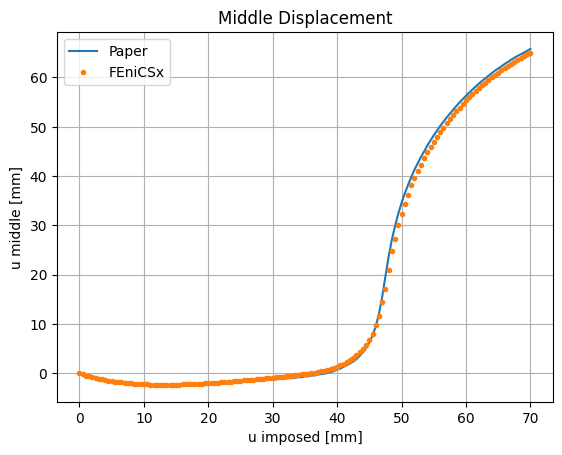

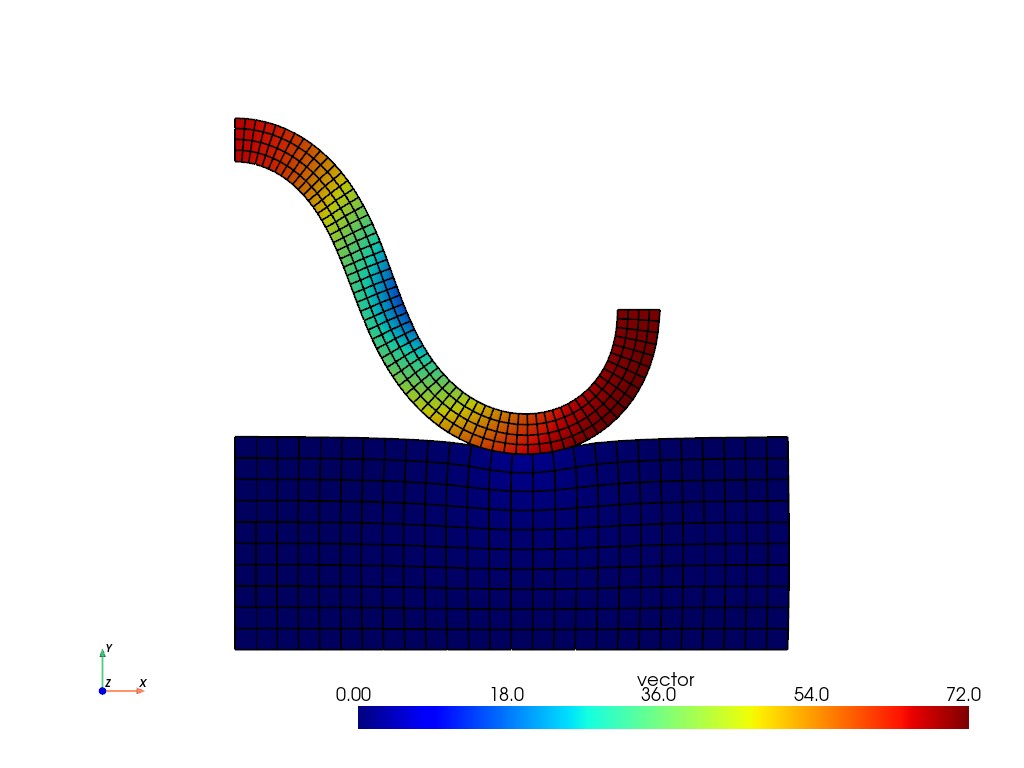

In [ ]:
ref_data = np.array([
    [0.0, 0.000],
    [0.5, -0.291],
    [1.0, -0.438],
    [1.5, -0.613],
    [2.0, -0.787],
    [2.5, -0.961],
    [3.0, -1.135],
    [3.5, -1.244],
    [4.0, -1.309],
    [4.5, -1.483],
    [5.0, -1.571],
    [5.5, -1.658],
    [6.0, -1.832],
    [6.5, -1.832],
    [7.0, -1.919],
    [7.5, -2.006],
    [8.0, -2.006],
    [8.5, -2.180],
    [9.0, -2.180],
    [9.5, -2.180],
    [10.0, -2.265],
    [10.5, -2.354],
    [11.0, -2.354],
    [11.5, -2.354],
    [12.0, -2.354],
    [12.5, -2.354],
    [13.0, -2.354],
    [13.5, -2.354],
    [14.0, -2.354],
    [14.5, -2.354],
    [15.0, -2.354],
    [15.5, -2.354],
    [16.0, -2.354],
    [16.5, -2.354],
    [17.0, -2.354],
    [17.5, -2.354],
    [18.0, -2.354],
    [18.5, -2.267],
    [19.0, -2.188],
    [19.5, -2.180],
    [20.0, -2.180],
    [20.5, -2.180],
    [21.0, -2.180],
    [21.5, -2.093],
    [22.0, -2.006],
    [22.5, -2.006],
    [23.0, -2.006],
    [23.5, -1.919],
    [24.0, -1.832],
    [24.5, -1.832],
    [25.0, -1.832],
    [25.5, -1.745],
    [26.0, -1.658],
    [26.5, -1.658],
    [27.0, -1.658],
    [27.5, -1.483],
    [28.0, -1.483],
    [28.5, -1.483],
    [29.0, -1.396],
    [29.5, -1.309],
    [30.0, -1.309],
    [30.5, -1.222],
    [31.0, -1.135],
    [31.5, -1.135],
    [32.0, -1.048],
    [32.5, -0.961],
    [33.0, -0.961],
    [33.5, -0.874],
    [34.0, -0.787],
    [34.5, -0.787],
    [35.0, -0.613],
    [35.5, -0.613],
    [36.0, -0.449],
    [36.5, -0.438],
    [37.0, -0.264],
    [37.5, -0.160],
    [38.0, -0.090],
    [38.5, 0.084],
    [39.0, 0.258],
    [39.5, 0.432],
    [40.0, 0.781],
    [40.5, 0.955],
    [41.0, 1.303],
    [41.5, 1.628],
    [42.0, 2.000],
    [42.5, 2.401],
    [43.0, 2.879],
    [43.5, 3.523],
    [44.0, 4.258],
    [44.5, 5.167],
    [45.0, 6.234],
    [45.5, 7.638],
    [46.0, 9.495],
    [46.5, 12.071],
    [47.0, 15.535],
    [47.5, 19.683],
    [48.0, 23.658],
    [48.5, 27.119],
    [49.0, 29.894],
    [49.5, 32.399],
    [50.0, 34.537],
    [50.5, 36.480],
    [51.0, 38.155],
    [51.5, 39.758],
    [52.0, 41.269],
    [52.5, 42.565],
    [53.0, 43.860],
    [53.5, 44.982],
    [54.0, 46.191],
    [54.5, 47.226],
    [55.0, 48.260],
    [55.5, 49.208],
    [56.0, 50.155],
    [56.5, 51.021],
    [57.0, 51.876],
    [57.5, 52.665],
    [58.0, 53.423],
    [58.5, 54.196],
    [59.0, 54.945],
    [59.5, 55.605],
    [60.0, 56.253],
    [60.5, 56.941],
    [61.0, 57.549],
    [61.5, 58.140],
    [62.0, 58.739],
    [62.5, 59.299],
    [63.0, 59.821],
    [63.5, 60.343],
    [64.0, 60.866],
    [64.5, 61.386],
    [65.0, 61.811],
    [65.5, 62.259],
    [66.0, 62.722],
    [66.5, 63.130],
    [67.0, 63.582],
    [67.5, 64.001],
    [68.0, 64.349],
    [68.5, 64.698],
    [69.0, 65.046],
    [69.5, 65.394],
    [70.0, 65.794]
])

u_imposed_ref   = ref_data[:, 0]
u_ref           = ref_data[:, 1]

plt.plot(u_imposed_ref, u_ref)
plt.plot(-u_imposed, u_fenicsx, ".")
plt.legend(["Paper", "FEniCSx"])
plt.xlabel("u imposed [mm]")
plt.ylabel("u middle [mm]")
plt.title("Middle Displacement")
plt.grid(True)
plt.show()

viskex.dolfinx.plot_vector_field(uh, warp_factor=1)